In [1]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the path to the folder where the notebook is located
current_dir = os.path.dirname(os.path.abspath('data_exploration.ipynb'))

# Append the 'src' folder to the system path
src_dir = os.path.join(current_dir, '..', 'src')
sys.path.append(src_dir)
from data_preprocessing import return_assistments_df

In [2]:
df_data = return_assistments_df()
df_data.head()

,order_id,user_id,correct,skill_id,ms_first_response,bottom_hint
3957,21617623,14,0,2,26271,1.0
94047,21617623,14,0,37,26271,1.0
172411,21617623,14,0,70,26271,1.0
3958,21617632,14,1,2,29123,NaN
94048,21617632,14,1,37,29123,NaN


In [3]:
df_data.describe()

,order_id,user_id,correct,skill_id,ms_first_response,bottom_hint
count,4.592080e+05,459208.000000,459208.000000,459208.000000,4.592080e+05,62572.000000
mean,3.167988e+07,82507.492881,0.690373,155.697516,5.069205e+04,0.737103
std,4.898721e+06,6953.108289,0.462340,127.620640,3.292125e+05,0.440211
min,2.022408e+07,14.000000,0.000000,1.000000,-7.759575e+06,0.000000
25%,2.851583e+07,78552.000000,0.000000,47.000000,8.509750e+03,0.000000
50%,3.334980e+07,79055.000000,1.000000,81.000000,2.303600e+04,1.000000
75%,3.511800e+07,86325.000000,1.000000,297.000000,5.421800e+04,1.000000
max,3.831020e+07,96299.000000,1.000000,378.000000,8.407692e+07,1.000000


In [10]:
print("Number of rows:", len(df_data))
print("Number of distinct users:", df_data['user_id'].nunique())
print("Number of distinct skills:", df_data['skill_id'].nunique())

Number of rows: 459208
Number of distinct users: 4163
Number of distinct skills: 123


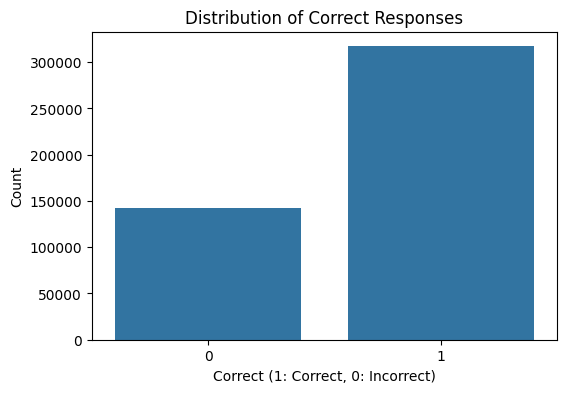

In [4]:


plt.figure(figsize=(6, 4))
sns.countplot(x='correct', data=df_data)
plt.title('Distribution of Correct Responses')
plt.xlabel('Correct (1: Correct, 0: Incorrect)')
plt.ylabel('Count')
plt.show()


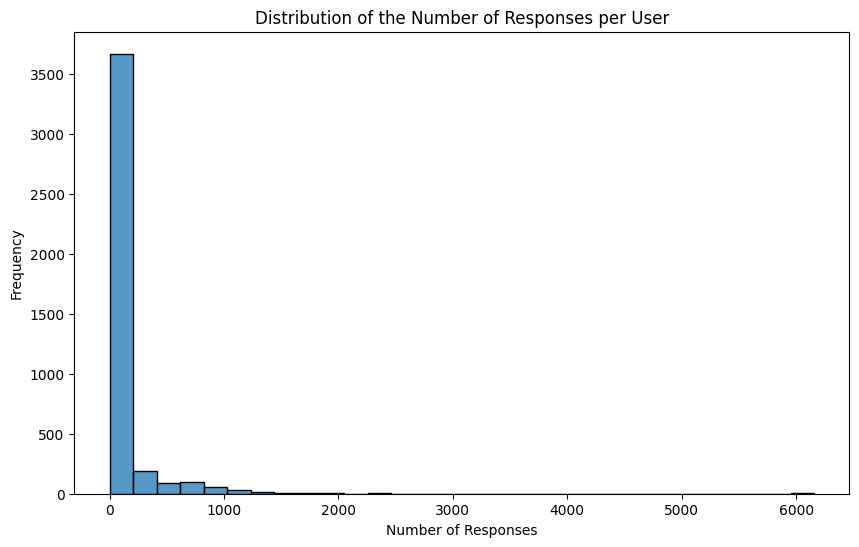

In [8]:
user_activity = df_data['user_id'].value_counts()
plt.figure(figsize=(10, 6))
sns.histplot(user_activity, bins=30, kde=False)
plt.title('Distribution of the Number of Responses per User')
plt.xlabel('Number of Responses')
plt.ylabel('Frequency')

plt.show()


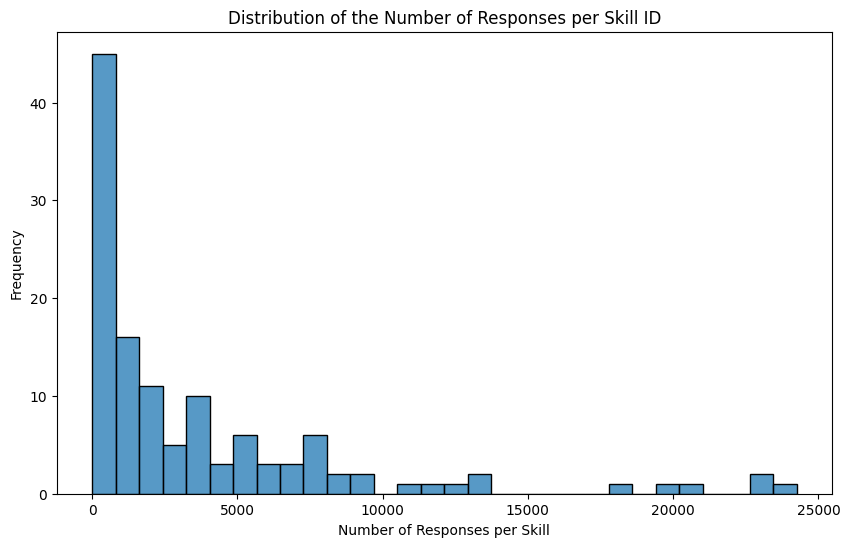

In [9]:
skill_counts = df_data['skill_id'].value_counts()
plt.figure(figsize=(10, 6))
sns.histplot(skill_counts, bins=30, kde=False) 
plt.title('Distribution of the Number of Responses per Skill ID')
plt.xlabel('Number of Responses per Skill')
plt.ylabel('Frequency')

plt.show()

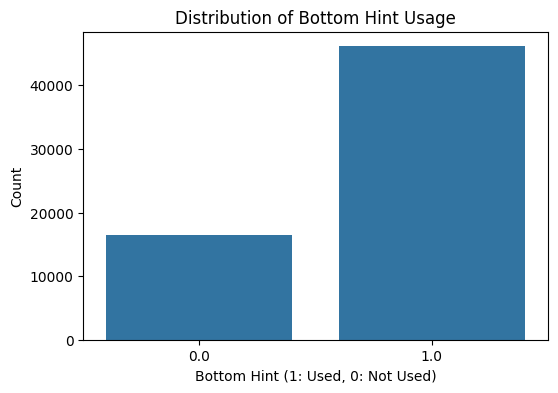

In [15]:
# Countplot for bottom_hint
plt.figure(figsize=(6, 4))
sns.countplot(x='bottom_hint', data=df_data)
plt.title('Distribution of Bottom Hint Usage')
plt.xlabel('Bottom Hint (1: Used, 0: Not Used)')
plt.ylabel('Count')
plt.show()



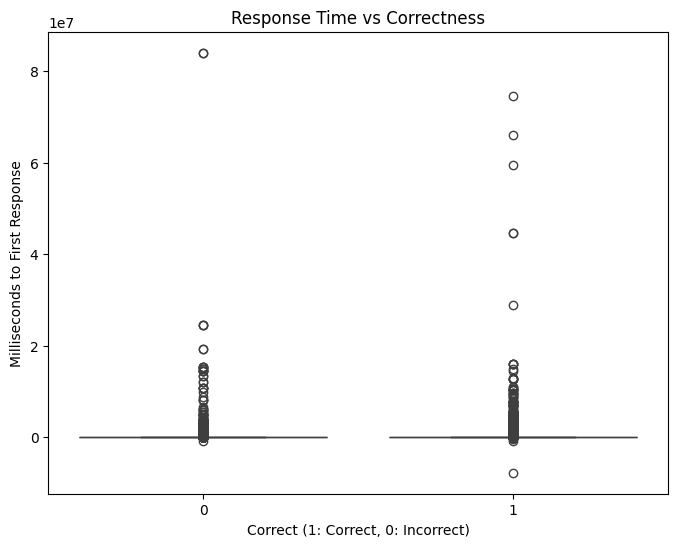

In [12]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='correct', y='ms_first_response', data=df_data)
plt.title('Response Time vs Correctness')
plt.xlabel('Correct (1: Correct, 0: Incorrect)')
plt.ylabel('Milliseconds to First Response')
plt.show()


In [28]:
sorted(df_data['ms_first_response'].unique())

[np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0),
 np.float64(22.0),
 np.float64(138.0),
 np.float64(139.0),
 np.float64(150.0),
 np.float64(160.0),
 np.float64(167.0),
 np.float64(171.0),
 np.float64(179.0),
 np.float64(187.0),
 np.float64(200.0),
 np.float64(204.0),
 np.float64(211.0),
 np.float64(227.0),
 np.float64(239.0),
 np.float64(251.0),
 np.float64(283.0),
 np.float64(293.0),
 np.float64(297.0),
 np.float64(299.0),
 np.float64(303.0),
 np.float64(315.0),
 np.float64(324.0),
 np.float64(359.0),
 np.float64(390.0),
 np.float64(406.0),
 np.float64(411.0),
 np.float64(414.0),
 np.float64(415.0),
 np.float64(491.0),
 np.float64(501.0),
 np.float64(503.0),
 np.float64(520.0),
 np.float64(527.0),
 np.float64(528.0),
 np.float64(530.0),
 np.float64(532.0),
 np.float64(535.0),
 np.float64(544.0),
 np.float64(547.0),
 np.float64(562.0),
 np.float64(563.0),
 np.float64(567.0),
 np.float64(570.0),
 np.float64(579.0),
 np.float64(585.0),
 np.float64(603.0),
 np.float

In [27]:
# Replace negative values in 'ms_first_response' with np.nan
df_data['ms_first_response'] = df_data['ms_first_response'].apply(lambda x: np.nan if x < 0 else x)
